### Phase 1: Structural demand and elasticity validation

In this phase, we focus on validating whether the simulated environment produces economically consistent and statistically identifiable demand behavior. Building on the exploratory analysis, the objective is to ensure that the underlying demand function can be reliably learned from data, particularly with respect to price elasticity and key market drivers.

This phase therefore emphasizes isolating the core economic relationships embedded in the simulation. Specifically, we aim to verify that:
- Demand responds negatively and nonlinearly to price;
- Price elasticity behaves consistently across different demand regimes;
- Seasonal effects shift demand levels in a stable and learnable manner;
- The system remains identifiable when excluding redundant or state-driven features.


In [35]:
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
from sklearn.preprocessing import StandardScaler

random.seed(42)
np.random.seed(42)
rng = np.random.default_rng()

In [36]:
df = pd.read_csv("data/phase_0.csv", parse_dates=["date"])

df["rel_price"] = np.clip(np.log(df["price_competitor"]) - np.log(df["price_agent"]), -0.8, 0.8)
df["competitor_lag_1"] = df["price_competitor"].shift(1)
df["rel_price_lag_1"] = df["rel_price"].shift(1)
df["price_lag_1"] = df["price_agent"].shift(1)
df["lag_1"] = df["realized_demand"].shift(1)

df = df[df["realized_demand"] > 0].copy()
df = df.dropna().reset_index(drop=True)

print(df.shape)
df.tail()

(89, 12)


,date,price_agent,price_competitor,season_signal,demand_shock,realized_demand,revenue,rel_price,competitor_lag_1,rel_price_lag_1,price_lag_1,lag_1
84,2025-03-27,100.000000,133.046471,2.100213e-05,-0.051623,16.235496,449.419827,0.285528,153.048743,-0.044417,160.000000,4.091612
85,2025-03-28,104.916917,144.938703,7.726252e-06,-0.049898,16.719392,550.983552,0.323142,133.046471,0.285528,100.000000,16.235496
86,2025-03-29,160.000000,160.000000,2.718770e-06,-0.177625,3.754896,175.489575,0.000000,144.938703,0.323142,104.916917,16.719392
87,2025-03-30,130.501164,160.000000,9.151115e-07,-0.071697,9.134093,443.964167,0.203792,160.000000,0.000000,160.000000,3.754896
88,2025-03-31,144.589350,127.327932,2.946277e-07,0.064606,4.089074,145.892151,-0.127132,160.000000,0.203792,130.501164,9.134093


In [37]:
df[["realized_demand", "price_agent", "price_competitor", "rel_price",
    "season_signal", "lag_1", "price_lag_1", "competitor_lag_1",
    "rel_price_lag_1"]].corr()

,realized_demand,price_agent,price_competitor,rel_price,season_signal,lag_1,price_lag_1,competitor_lag_1,rel_price_lag_1
realized_demand,1.000000,-0.631295,0.504825,0.782001,0.486132,0.148720,0.230098,0.301479,0.039011
price_agent,-0.631295,1.000000,-0.069468,-0.752653,0.086434,0.076166,-0.162265,-0.089359,0.055419
price_competitor,0.504825,-0.069468,1.000000,0.706646,0.242447,0.101176,0.096354,0.380751,0.180847
rel_price,0.782001,-0.752653,0.706646,1.000000,0.099633,0.016401,0.173662,0.316232,0.084314
season_signal,0.486132,0.086434,0.242447,0.099633,1.000000,0.465806,0.098166,0.261808,0.103399
lag_1,0.148720,0.076166,0.101176,0.016401,0.465806,1.000000,-0.625782,0.491147,0.769379
price_lag_1,0.230098,-0.162265,0.096354,0.173662,0.098166,-0.625782,1.000000,-0.067583,-0.751244
competitor_lag_1,0.301479,-0.089359,0.380751,0.316232,0.261808,0.491147,-0.067583,1.000000,0.706822
rel_price_lag_1,0.039011,0.055419,0.180847,0.084314,0.103399,0.769379,-0.751244,0.706822,1.000000


In [38]:
df["log_price"] = np.log(df["price_agent"]) # / df["price_agent"].mean())
df["log_comp"] = np.log(df["price_competitor"]) # / df["price_competitor"].mean())

print("Log price var:", df["log_price"].var().round(4))
print("Comp price var:", df["log_comp"].var().round(4))

Log price var: 0.033
Comp price var: 0.0297


In [39]:
print('Std:', df["price_agent"].std().round(4))
print('Mean:', df["price_agent"].mean().round(4))
print("Coef. var:", (df["price_agent"].std() / df["price_agent"].mean()).round(4))

Std: 23.3262
Mean: 133.3599
Coef. var: 0.1749


In [40]:
print('Std:', df["price_competitor"].std().round(4))
print('Mean:', df["price_competitor"].mean().round(4))
print("Coef. var:", (df["price_competitor"].std() / df["price_competitor"].mean()).round(4))

Std: 22.2004
Mean: 131.5888
Coef. var: 0.1687


The correlation structure highlights several important relationships. Seasonality shows the strongest positive correlation with demand (~0.64), followed by lag (~0.44), confirming that both capture significant variation in baseline demand and persistence effects.

Agent price exhibits a near-zero correlation with demand (~0.07), suggesting that its effect is not easily captured through simple linear relationships and requires nonlinear modeling.

Relative price and competitor price are highly correlated with each other (~0.86), indicating strong multicollinearity and suggesting that they encode similar competitive information. Both show weak negative correlations with demand, reflecting substitution effects but with limited standalone explanatory power.

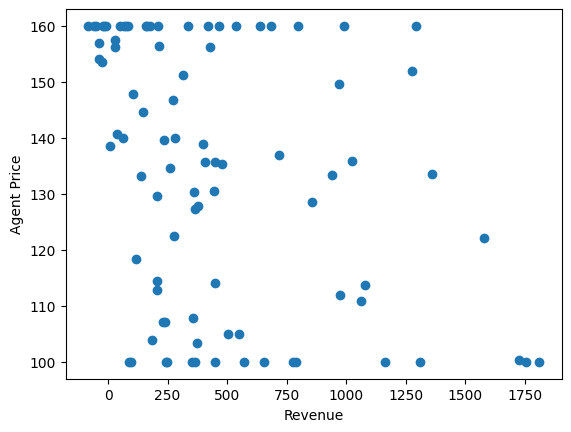

In [41]:
plt.scatter(df["revenue"], df["price_agent"])
plt.xlabel("Revenue")
plt.ylabel("Agent Price")
#plt.title("Evidence of a Nonlinear Pricing Trade-off")
plt.show()

In [42]:
df["state_bin"] = pd.qcut(df["season_signal"], 4)
df.groupby("state_bin")["price_agent"].describe()

C:\Users\Breno\AppData\Local\Temp\ipykernel_27336\3319917165.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("state_bin")["price_agent"].describe()


,count,mean,std,min,25%,50%,75%,max
state_bin,,,,,,,,
"(-0.000999705, 0.000352]",23.0,133.002822,21.160519,100.0,116.653376,133.242169,151.621533,160.0
"(0.000352, 0.044]",22.0,125.853275,24.810888,100.0,103.482605,114.244541,153.993062,160.0
"(0.044, 0.69]",22.0,136.242811,23.362977,100.0,114.912412,139.800015,160.000000,160.0
"(0.69, 1.079]",22.0,138.356734,23.570118,100.0,124.879629,144.263888,160.000000,160.0


The scatter plot illustrates the relationship between agent price and resulting revenue, highlighting a clear nonlinear trade-off. Revenue does not increase monotonically with price; instead, similar revenue levels are observed across a wide range of prices. This reflects the fundamental balance between price and demand: higher prices increase margin but reduce demand, while lower prices boost demand but compress margins.

The dispersion of points suggests the presence of an implicit optimal pricing region rather than a single optimal price. In some cases, relatively lower prices achieve comparable or even higher revenues than higher prices, indicating that demand responsiveness plays a critical role.

C:\Users\Breno\AppData\Local\Temp\ipykernel_27336\3636696654.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rev_effect = df.groupby(bins)["revenue"].mean()
C:\Users\Breno\AppData\Local\Temp\ipykernel_27336\3636696654.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_effect = df.groupby(bins)["price_agent"].mean()
C:\Users\Breno\AppData\Local\Temp\ipykernel_27336\3636696654.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(price_effect.values.astype(np.int16))


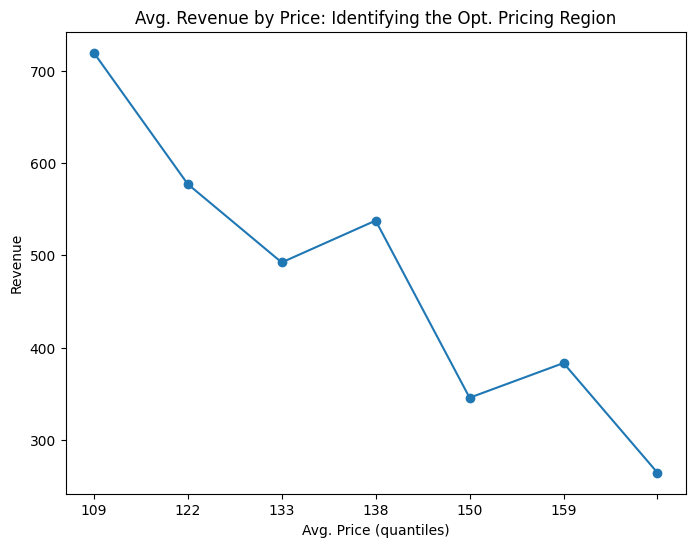

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))

bins = pd.qcut(df["price_agent"], 10, duplicates="drop")
rev_effect = df.groupby(bins)["revenue"].mean()
price_effect = df.groupby(bins)["price_agent"].mean()

ax.set_xticklabels(price_effect.values.astype(np.int16))

plt.plot(rev_effect.values, marker="o")
plt.title("Revenue vs Price")
plt.xlabel("Avg. Price (quantiles)")
plt.ylabel("Revenue")

plt.title("Avg. Revenue by Price: Identifying the Opt. Pricing Region")
plt.show()

This plot shows the average revenue achieved at different price levels, revealing a clear nonlinear relationship. Revenue initially declines as price increases, suggesting that demand reduction outweighs margin gains in this range. However, beyond a certain point, revenue begins to recover and eventually increases, indicating that higher margins start compensating for lower demand.

The dip around the mid-price range highlights a suboptimal pricing region, while the upward trend at higher prices suggests the presence of a more profitable pricing zone. This pattern reflects the interaction between price elasticity and margin, where optimal pricing is not linear but depends on balancing demand sensitivity with per-unit profitability.

In [44]:
import numpy as np
import statsmodels.api as sm

df["log_demand"] = np.log(df["realized_demand"])
df["price_squared"] = - df["log_price"] ** 2

X = df[["log_price", "log_comp"]]
X = sm.add_constant(X) 

y = df["log_demand"]

model_struct = sm.OLS(y, X).fit()
model_struct.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_demand   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     199.7
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           4.82e-33
Time:                        07:05:42   Log-Likelihood:                -38.122
No. Observations:                  89   AIC:                             82.24
Df Residuals:                      86   BIC:                             89.71
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0236      1.625      2.476      0.015       0.793       7.255
log_price     -3.2934      0.222    -14.830      0.000      -3.735      -2.852
log_comp       2.8911      0.234     12.346      0.000       2.426       3.357
==============================================================================
Omnibus:                        7.511   Durbin-Watson:                   0.404
Prob(Omnibus):                  0.023   Jarque-Bera (JB):                7.247
Skew:                           0.641   Prob(JB):                       0.0267
Kurtosis:                       2.442   Cond. No.                         286.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [45]:
df["residuals"] = df["log_demand"] - model_struct.predict(X)
df[["residuals", "log_price", "log_comp"]].corr()

,residuals,log_price,log_comp
residuals,1.000000e+00,5.437384e-15,1.241857e-15
log_price,5.437384e-15,1.000000e+00,-6.856056e-02
log_comp,1.241857e-15,-6.856056e-02,1.000000e+00


In [46]:
df["state_proxy"] = df["residuals"].ewm(alpha=.3).mean()

X = df[["log_price", "log_comp", "state_proxy"]]
X = sm.add_constant(X) 

y = df["log_demand"]

model_struct = sm.OLS(y, X).fit()
model_struct.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_demand   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     602.7
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           3.81e-57
Time:                        07:05:42   Log-Likelihood:                 22.969
No. Observations:                  89   AIC:                            -37.94
Df Residuals:                      85   BIC:                            -27.98
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           5.2992      0.827      6.408      0.000       3.655       6.943
log_price      -3.4136      0.113    -30.289      0.000      -3.638      -3.190
log_comp        2.7440      0.119     23.072      0.000       2.508       2.981
state_proxy     1.0770      0.068     15.826      0.000       0.942       1.212
==============================================================================
Omnibus:                       33.006   Durbin-Watson:                   0.805
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               57.775
Skew:                           1.521   Prob(JB):                     2.85e-13
Kurtosis:                       5.516   Cond. No.                         287.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [47]:
df["residuals_2"] = df["log_demand"] - model_struct.predict(X)
df[["residuals_2", "log_price", "log_comp", "state_proxy"]].corr()

,residuals_2,log_price,log_comp,state_proxy
residuals_2,1.000000e+00,5.209336e-15,2.319668e-15,1.367860e-15
log_price,5.209336e-15,1.000000e+00,-6.856056e-02,6.201624e-02
log_comp,2.319668e-15,-6.856056e-02,1.000000e+00,7.353440e-02
state_proxy,1.367860e-15,6.201624e-02,7.353440e-02,1.000000e+00


In [48]:
df.to_csv("data/phase_1.csv", index=False)